## This notebook demonstrates how to create cutouts from DR2 Mosaics on the STRW cluster using the `strw_lofar_data_utils` package. It covers:
- Loading a source catalogue (discovered giants) and extracting RA/Dec coordinates
- Using the generate_cutouts pipeline to create cutouts from specified positions
- Visualizing individual cutouts with contour overlays using the Vizualizer class

# Import necessary libraries and modules:

In [1]:
import pandas as pd
import os

from src.pipelines import generate_cutouts
from src.core.vizualization import Vizualizer

# Load a catalogue from which we will extract the RA and Dec for cutout generation:

In [2]:
GIANTS_CATALOG = os.getcwd() + "/data/discovered_giants_catalogue.csv"
GIANTS_CATALOG

'/home/penchev/strw_lofar_data_utils/data/discovered_giants_catalogue.csv'

In [3]:
giants_df = pd.read_csv(GIANTS_CATALOG)
giants_df.head()

,recno,Name,RAJ2000,DEJ2000,LengthMpc,e_LengthMpc,LengthAng,z,e_z,Ref,FistDisc
0,10511,NaN,40.275764,8.737979,0.871,0.008,32.70,0.02121,0.00017,Oei et al. 2023,Oei et al. 2023
1,10358,NaN,38.802856,10.196330,1.014,0.607,15.60,0.05384,0.00000,Oei et al. 2023,Oei et al. 2023
2,10283,NaN,48.697044,15.149883,1.067,0.505,12.70,0.07104,0.00000,Oei et al. 2023,Oei et al. 2023
3,10938,NaN,42.945000,15.836940,0.918,0.000,2.46,0.48900,0.00000,Mahato et al. 2021,Mahato et al. 2021
4,10055,NaN,43.804028,17.514114,1.295,0.441,11.60,0.09725,0.00000,Oei et al. 2023,Oei et al. 2023


# Extract RA and Dec from the catalogue to define cutout regions:

In [4]:
# Get RA and DEC for the first 100 giants
ra_dec_list = list(
    zip(giants_df["RAJ2000"].values, giants_df["DEJ2000"].values)
)
ra_dec_list[:10]

[(40.275764, 8.737979),
 (38.802856, 10.19633),
 (48.697044, 15.149883),
 (42.945, 15.83694),
 (43.804028, 17.514114),
 (60.128278, 13.156841),
 (59.031086, 13.819252),
 (48.748005, 16.180998),
 (50.35795833333, 18.10273333333),
 (31.9861233, 16.96429532073)]

# Generate cutouts using the defined RA and Dec coordinates:

In [5]:
cutouts = generate_cutouts(
    ra_dec_list=ra_dec_list[:1000],
    size_pixels = 300,
    save=False
)

Generating cutouts: 100%|██████████| 1000/1000 [00:10<00:00, 92.17it/s]


In [6]:
print(f"Generated {len(cutouts)} cutouts.")

Generated 859 cutouts.


We have 859 generated cutouts because some of the RA and DEC are either too close to the edge of the mosaic (unlikely as we account for that) or are not in the DR2 coverage area (more likely).

# Show some of the generated cutouts:

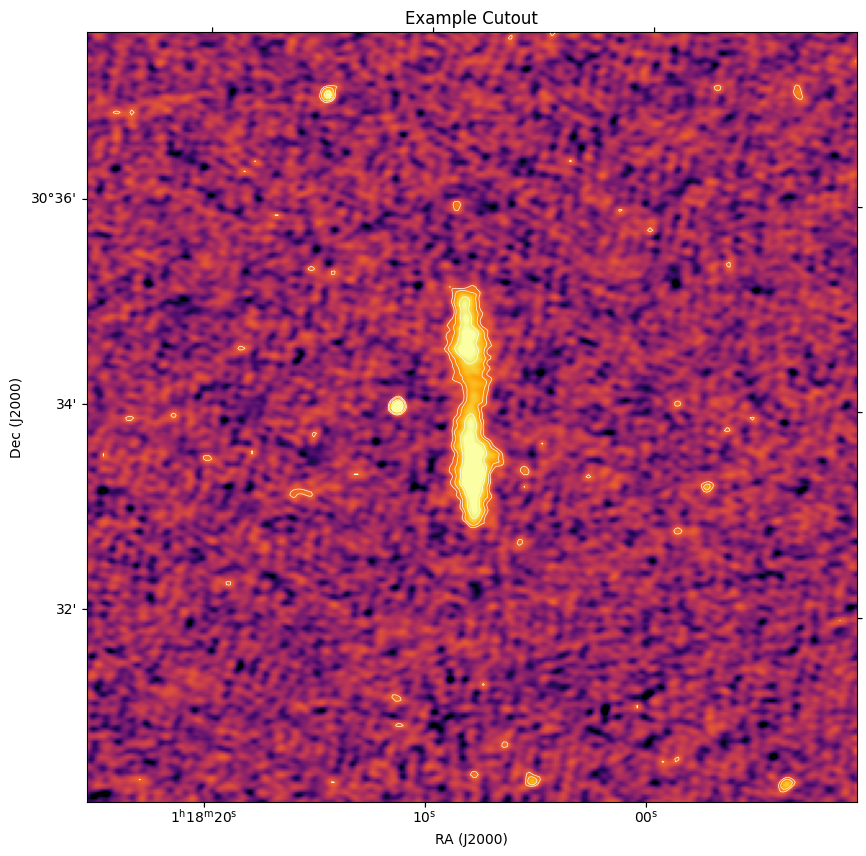

In [7]:
example_cutout = cutouts[420]

Vizualizer().vizualize_a_cutout(
    cutout=example_cutout,
    title="Example Cutout",
    contour_levels=[3, 5, 10]
)

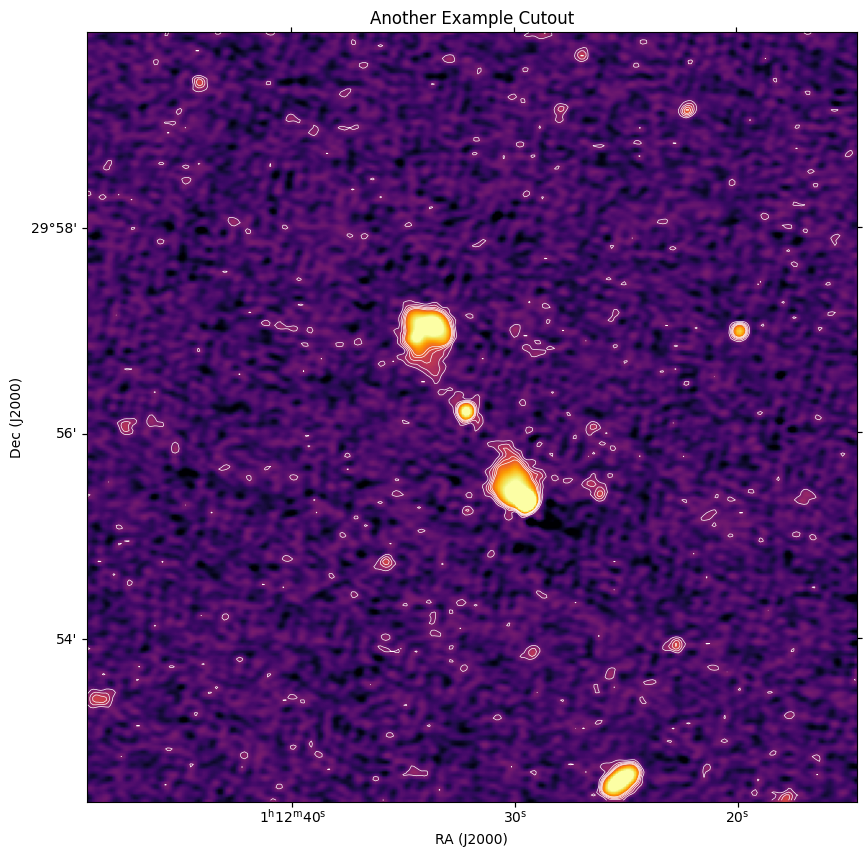

In [ ]:
another_example_cutout = cutouts[421]

Vizualizer().vizualize_a_cutout(
    cutout=another_example_cutout,
    title="Another Example Cutout",
    contour_levels=[3, 5, 10]
)